In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2


In [ ]:
os.listdir()

['jonjones.avif',
 'images',
 'Untitled.ipynb',
 'faces.csv',
 'Face_Detection_project.ipynb',
 'lionel-messi-22716478.webp',
 '.ipynb_checkpoints']

In [3]:
df = pd.read_csv('faces.csv')

In [4]:
df

,image_name,width,height,x0,y0,x1,y1
0,00001722.jpg,1333,2000,490,320,687,664
1,00001044.jpg,2000,1333,791,119,1200,436
2,00001050.jpg,667,1000,304,155,407,331
3,00001736.jpg,626,417,147,14,519,303
4,00003121.jpg,626,418,462,60,599,166
...,...,...,...,...,...,...,...
3345,00002232.jpg,620,349,4,36,186,158
3346,00002232.jpg,620,349,122,103,344,248
3347,00002232.jpg,620,349,258,118,541,303
3348,00002232.jpg,620,349,215,11,362,108


In [5]:
img = mpimg.imread('images/00002232.jpg')

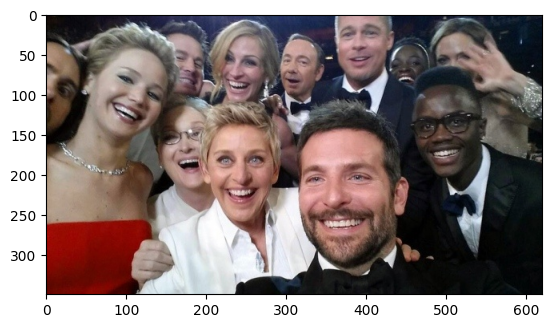

In [6]:
plt.imshow(img)

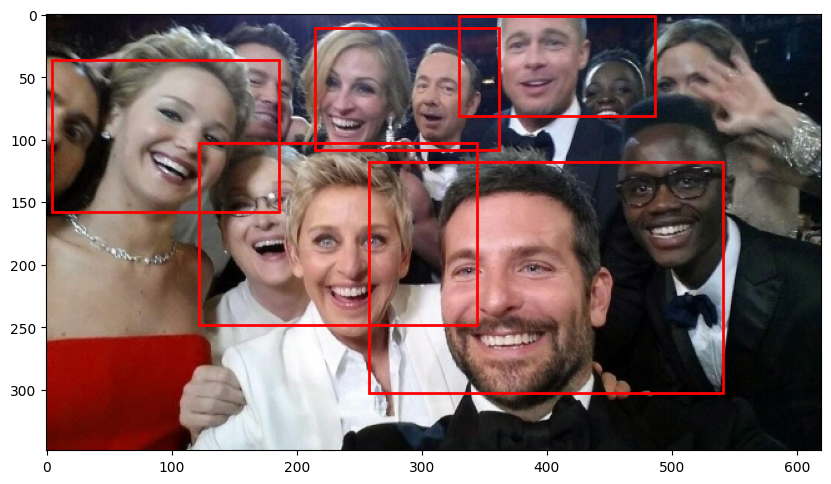

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Վերցնում ենք միայն այս նկարի տվյալները
image_df = df[df["image_name"] == "00002232.jpg"]

fig, ax = plt.subplots(figsize=(10, 6))

# Ցույց ենք տալիս նկարը
ax.imshow(img)

# Ամեն bounding box-ը նկարում ենք
for _, row in image_df.iterrows():
    x0 = row["x0"]
    y0 = row["y0"]
    x1 = row["x1"]
    y1 = row["y1"]

    width = x1 - x0
    height = y1 - y0

    rect = patches.Rectangle(
        (x0, y0),          # ձախ վերևի կետը
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rect)

plt.show()

In [8]:
X = []
y = []
for i in range(0, len(df)):
    try:
        image_name = df.iloc[i]['image_name']
        x0 = df.iloc[i]['x0']
        y0 = df.iloc[i]['y0']
        x1 = df.iloc[i]['x1']
        y1 = df.iloc[i]['y1']
        w = df.iloc[i]['width']
        h = df.iloc[i]['height']
        img = mpimg.imread(f'images/{image_name}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (100,100))
        img = img.reshape(100,100,1)
        img = img / 255
        x0 = x0 * 100 / w
        y0 = y0 * 100 / h
        x1 = x1 * 100 / w
        y1 = y1 * 100 / h
        X.append(img)
        y.append([x0,y0,x1,y1])
    except Exception as e:
        print(e)
        
        
        
    

In [ ]:
X = np.array(X)
y = np.array(y)
y.shape

In [ ]:
from keras import Sequential
from keras.layers import Conv2D, Flatten, MaxPool2D, Dense
from keras.optimizers import Adam

In [ ]:
model = Sequential()
model.add(Conv2D(filters = 32, kernel_size = (3,3), padding='same', activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPool2D(2,2))
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

model.add(Dense(4, activation='linear'))





In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

In [ ]:
model.fit(X, y, validation_split=0.2, epochs=20)

In [ ]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.legend(['loss', 'val_loss'])

In [ ]:
original = mpimg.imread('jonjones.avif')

In [ ]:
imgtest = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
imgtest = cv2.resize(imgtest, (100, 100))
imgtest = imgtest.reshape(1, 100, 100, 1)
imgtest = imgtest / 255

In [54]:
x0, y0, x1, y1 = model.predict(imgtest).astype(int)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [55]:
print(x0, y0, x1, y1)

44 5 74 40


In [56]:
h, w = original.shape[:2]

In [57]:
x0 = x0 * w / 100
x1 = x1 * w / 100

y0 = y0 * h / 100
y1 = y1 * h / 100

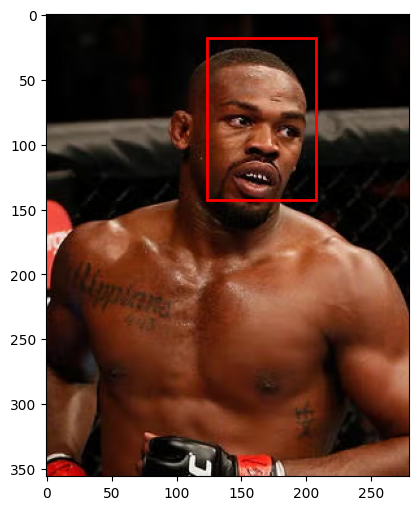

In [65]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(original)

rect = patches.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(rect)

plt.show()